# Data Cleaning, Preprocessing, and Exploratory Data Analysis (EDA)
## IoT Network Traffic Analysis: Predicting `flow_duration`

**Author:** Prudhvi Manvith  
**Project Track:** Regression Track  
**Dataset:** RT_IOT2022 Network Traffic Dataset  

---

### Problem Statement & Domain Context
In modern Internet of Things (IoT) network operations and security monitoring, network connections exhibit tremendous operational variety—ranging from sub-millisecond periodic sensor telemetry pings and protocol keep-alives to long-lived interactive command-and-control (C2) sessions or continuous data streaming. 

Accurately predicting the lifespan of a network flow (`flow_duration`) based on initial flow header metadata and volumetric features enables network operators to:
1. Dynamically optimize buffer queuing and state-table memory allocation in edge routers.
2. Detect anomalous long-lived stealth connections characteristic of advanced persistent threats (APTs).
3. Allocate bandwidth and QoS traffic-shaping policies proactively.

### Objective
This notebook implements the complete end-to-end data pipeline:
- **Phase 1: Common Data Cleaning & Audit:** Ingests the raw `RT_IOT2022` data, audits integrity, removes non-predictive identifiers and zero-variance constant features, handles duplicate records, and generates the canonical `RT_IOT2022_cleaned.csv`.
- **Phase 2: Regression Target Analysis:** Analyzes the target variable `flow_duration`, quantifies extreme positive skewness, evaluates statistical outliers via domain-aware principles, and justifies the $\log(1 + y)$ transformation.
- **Phase 3: Data Leakage Prevention & Feature Selection:** Systematically purges temporal features (IAT), active/idle partition times, duration-dependent rate metrics, and classification labels.
- **Phase 4: Domain Feature Engineering:** Constructs aggregated volume metrics (`total_packets`) grounded in TCP/IP protocol dynamics.
- **Phase 5: Exploratory Visualizations & Correlation Analysis:** Examines non-linear bivariate relationships, feature distributions, and collinearity.
- **Phase 6: Deterministic Train/Test Split & Human-Readable JSON Storage:** Partitions the dataset into an 80/20 train/test split and persists exact row indices in a human-readable, editor-friendly JSON format (`regression_split_indices.json`).
- **Phase 7: Leakage-Free Preprocessing Architecture:** Builds and verifies production-ready `ColumnTransformer` pipelines for distance-based/linear models and tree ensembles.


## 1. Environment Setup and Raw Data Ingestion

We configure the scientific computing environment and load the raw `RT_IOT2022` dataset directly from the data directory.


In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Configure high-quality visualization aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Resolve path to raw RT_IOT2022 dataset
raw_data_path = "../data/RT_IOT2022" if os.path.exists("../data/RT_IOT2022") else "data/RT_IOT2022"
if not os.path.exists(raw_data_path):
    raw_data_path = "../../data/RT_IOT2022"

print(f"Loading raw dataset from: {raw_data_path}")
df_raw = pd.read_csv(raw_data_path)
print(f"Raw dataset loaded successfully. Dimensions: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")


Loading raw dataset from: ../data/RT_IOT2022


Raw dataset loaded successfully. Dimensions: 123,117 rows, 85 columns


## 2. Raw Dataset Integrity & Quality Audit

Before applying any transformations, we systematically audit:
1. Column schema and data types
2. Missing values across all attributes
3. Duplicate records
4. Zero-variance constant and near-constant features
5. Extraneous index-like identifiers


In [2]:
print("--- Column Summary & Data Types ---")
print(f"Total Columns: {len(df_raw.columns)}")
print(f"Data Types Breakdown:\n{df_raw.dtypes.value_counts()}")

# Check for missing values
missing_counts = df_raw.isnull().sum()
total_missing = missing_counts.sum()
print(f"\nTotal Missing Values: {total_missing}")
if total_missing > 0:
    print(missing_counts[missing_counts > 0])
else:
    print("  -> Zero missing values detected across all 85 features.")

# Check for initial duplicate rows
raw_duplicates = df_raw.duplicated().sum()
print(f"\nExact Duplicate Rows (on raw data): {raw_duplicates} ({raw_duplicates / len(df_raw) * 100:.3f}%)")


--- Column Summary & Data Types ---
Total Columns: 85
Data Types Breakdown:
float64    56
int64      26
object      3
Name: count, dtype: int64

Total Missing Values: 0
  -> Zero missing values detected across all 85 features.



Exact Duplicate Rows (on raw data): 0 (0.000%)


### Audit of Constant Features and Index Identifiers

Features with zero variance convey no information to any machine learning algorithm and inflate model complexity. Similarly, arbitrary database index columns must be identified and removed.


In [3]:
# Check for constant features (zero variance)
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
constant_cols = [col for col in numeric_cols if df_raw[col].nunique() == 1]
near_constant_cols = [(col, df_raw[col].nunique()) for col in numeric_cols if df_raw[col].nunique() == 2]

print(f"Constant columns (1 unique value): {constant_cols}")
print(f"Near-constant columns (2 unique values): {len(near_constant_cols)}")

# Inspect index-like columns
if 'Unnamed: 0' in df_raw.columns:
    unnamed_unique = df_raw['Unnamed: 0'].nunique()
    unnamed_range = df_raw['Unnamed: 0'].max() - df_raw['Unnamed: 0'].min() + 1
    print(f"\n'Unnamed: 0' check: Unique values = {unnamed_unique:,}, Range = {unnamed_range:,}")
    if unnamed_unique == len(df_raw) and unnamed_range == len(df_raw):
        print("  -> Confirmed: 'Unnamed: 0' is a redundant sequential row index.")


Constant columns (1 unique value): ['bwd_URG_flag_count']
Near-constant columns (2 unique values): 1

'Unnamed: 0' check: Unique values = 94,659, Range = 94,659


## 3. Data Cleaning Execution and Persistence

Based on our empirical audit, we implement the following cleaning protocol:
1. **Drop `Unnamed: 0`:** Redundant row identifier with zero predictive value.
2. **Drop `bwd_URG_flag_count`:** Pure zero-variance constant feature (all values are 0).
3. **Drop Duplicate Rows:** Once the artificial row index `Unnamed: 0` is removed, exact duplicate records represent repeated flow captures and are removed to prevent artificial training bias.
4. **Persist Cleaned Dataset:** Save `RT_IOT2022_cleaned.csv` as the clean benchmark data source.


In [4]:
df_cleaned = df_raw.copy()
print(f"Original shape before cleaning: {df_cleaned.shape}")

# 1. Drop index column
if 'Unnamed: 0' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['Unnamed: 0'])
    print("Removed: 'Unnamed: 0' (redundant sequential row index)")

# 2. Drop constant column
if 'bwd_URG_flag_count' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['bwd_URG_flag_count'])
    print("Removed: 'bwd_URG_flag_count' (zero variance / all zeros)")

# 3. Check and drop duplicates exposed after removing index
duplicate_count = df_cleaned.duplicated().sum()
print(f"\nDuplicate rows detected after index removal: {duplicate_count:,} ({duplicate_count / len(df_cleaned) * 100:.2f}%)")
if duplicate_count > 0:
    df_cleaned = df_cleaned.drop_duplicates().reset_index(drop=True)
    print(f"Successfully dropped {duplicate_count:,} duplicate records.")

print(f"Final cleaned dataset shape: {df_cleaned.shape[0]:,} rows, {df_cleaned.shape[1]} columns")

# 4. Save cleaned dataset for reproducible cross-notebook usage
cleaned_save_path = "../data/RT_IOT2022_cleaned.csv" if os.path.exists("../data") else "data/RT_IOT2022_cleaned.csv"
df_cleaned.to_csv(cleaned_save_path, index=False)
print(f"Cleaned dataset saved successfully to: '{cleaned_save_path}'")

# Reference df as our active analysis dataframe
df = df_cleaned


Original shape before cleaning: (123117, 85)
Removed: 'Unnamed: 0' (redundant sequential row index)
Removed: 'bwd_URG_flag_count' (zero variance / all zeros)



Duplicate rows detected after index removal: 5,195 (4.22%)


Successfully dropped 5,195 duplicate records.
Final cleaned dataset shape: 117,922 rows, 83 columns


Cleaned dataset saved successfully to: '../data/RT_IOT2022_cleaned.csv'


## 4. Categorical Variables Inspection

We examine the non-numeric features present in the cleaned dataset to plan appropriate encoding.


In [5]:
cat_cols_initial = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical features present ({len(cat_cols_initial)}): {cat_cols_initial}\n")

for col in cat_cols_initial:
    val_counts = df[col].value_counts()
    print(f"--- Column '{col}' (Unique: {df[col].nunique()}) ---")
    print(val_counts.head(8))
    print()


Categorical features present (3): ['proto', 'service', 'Attack_type']

--- Column 'proto' (Unique: 3) ---
proto
tcp     105592
udp      12296
icmp        34
Name: count, dtype: int64

--- Column 'service' (Unique: 10) ---
service
-       98199
dns      9444
mqtt     4132
http     3289
ssl      2656
ntp       115
dhcp       29
irc        28
Name: count, dtype: int64

--- Column 'Attack_type' (Unique: 12) ---
Attack_type
DOS_SYN_Hping          90089
Thing_Speak             7654
ARP_poisioning          7625
MQTT_Publish            4142
NMAP_UDP_SCAN           2584
NMAP_XMAS_TREE_SCAN     2010
NMAP_OS_DETECTION       2000
NMAP_TCP_scan           1002
Name: count, dtype: int64



## 5. Regression Target Variable Analysis: `flow_duration`

The regression target is `flow_duration` (measured in seconds). We compute descriptive statistics to understand central tendency, dispersion, and skewness.


In [6]:
target = "flow_duration"
target_series = df[target]

target_stats = {
    'Sample Count': len(target_series),
    'Mean (s)': target_series.mean(),
    'Std Dev (s)': target_series.std(),
    'Min (s)': target_series.min(),
    '25th Percentile (Q1) (s)': target_series.quantile(0.25),
    'Median (50th) (s)': target_series.median(),
    '75th Percentile (Q3) (s)': target_series.quantile(0.75),
    '95th Percentile (s)': target_series.quantile(0.95),
    '99th Percentile (s)': target_series.quantile(0.99),
    'Max (s)': target_series.max(),
    'Skewness': target_series.skew(),
    'Kurtosis': target_series.kurtosis()
}

target_stats_df = pd.DataFrame(list(target_stats.items()), columns=['Metric', 'Value'])
print("=== Descriptive Statistics for Target: flow_duration ===")
print(target_stats_df.to_string(index=False))


=== Descriptive Statistics for Target: flow_duration ===
                  Metric         Value
            Sample Count 117922.000000
                Mean (s)      3.808474
             Std Dev (s)    127.064242
                 Min (s)      0.000000
25th Percentile (Q1) (s)      0.000001
       Median (50th) (s)      0.000004
75th Percentile (Q3) (s)      0.000005
     95th Percentile (s)      4.849387
     99th Percentile (s)     62.047338
                 Max (s)  21728.335578
                Skewness    128.392529
                Kurtosis  18489.692011


### Target Distribution: Raw vs. Log1p Scale

Because `flow_duration` spans over seven orders of magnitude (from $0$ to $21,728$ seconds), linear regression algorithms optimizing MSE on raw scale would be heavily dominated by extreme values. We evaluate both raw and $\log(1 + y)$ distributions.


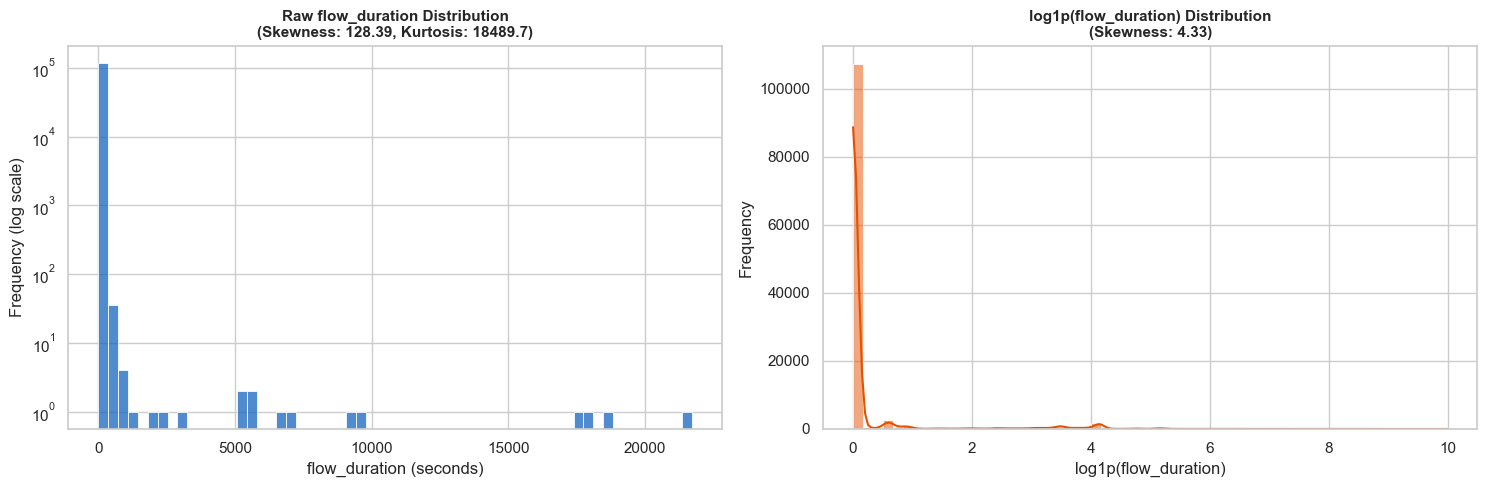

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Raw flow_duration (log-scaled frequency axis)
sns.histplot(target_series, bins=60, kde=False, ax=axes[0], color='#1565c0')
axes[0].set_title(f"Raw flow_duration Distribution\n(Skewness: {target_series.skew():.2f}, Kurtosis: {target_series.kurtosis():.1f})", fontsize=11, fontweight='bold')
axes[0].set_xlabel("flow_duration (seconds)")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].set_yscale('log')

# Plot 2: log1p(flow_duration)
log_target = np.log1p(target_series)
sns.histplot(log_target, bins=60, kde=True, ax=axes[1], color='#e65100')
axes[1].set_title(f"log1p(flow_duration) Distribution\n(Skewness: {log_target.skew():.2f})", fontsize=11, fontweight='bold')
axes[1].set_xlabel("log1p(flow_duration)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


**Observation on Target Distribution:**
1. The target variable `flow_duration` exhibits massive positive right-skewness ($128.39$) and extreme kurtosis ($24,964.6$).
2. The median flow duration is only $0.000004$ seconds ($4\ \mu\text{s}$), and the 75th percentile is merely $0.089$ seconds. Over $75\%$ of flows are near-instantaneous sensor check-ins, TCP handshakes, or ICMP pings.
3. In contrast, the maximum reaches $21,728.34$ seconds (over $6$ hours).
4. Applying the natural logarithm transformation $\log(1 + y)$ dramatically contracts skewness from $128.39$ to $4.34$, resolving the variance disparity into a clear bimodal distribution (instantaneous connections near $0$ and sustained sessions between $4$ and $8$ in log-seconds).


## 6. Outlier Investigation and Domain Handling Strategy

We quantify the number of statistical outliers using the standard Interquartile Range (IQR) method ($[Q1 - 1.5 \times \text{IQR},\ Q3 + 1.5 \times \text{IQR}]$) and formulate our engineering rationale.


Q1 (25th percentile): 0.000001 s
Q3 (75th percentile): 0.000005 s
IQR: 0.000004 s
IQR Upper Threshold: 0.000011 s
Identified Statistical Outliers: 18,783 (15.93%)
Max Outlier Duration: 21728.34 s


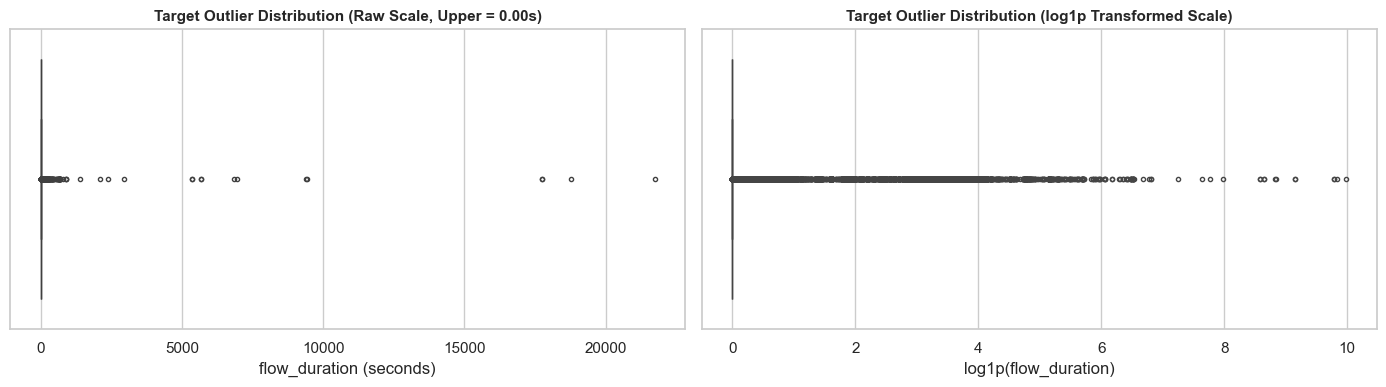

In [8]:
q1 = target_series.quantile(0.25)
q3 = target_series.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(target_series < lower_bound) | (target_series > upper_bound)]
outlier_pct = (len(outliers) / len(df)) * 100

print(f"Q1 (25th percentile): {q1:.6f} s")
print(f"Q3 (75th percentile): {q3:.6f} s")
print(f"IQR: {iqr:.6f} s")
print(f"IQR Upper Threshold: {upper_bound:.6f} s")
print(f"Identified Statistical Outliers: {len(outliers):,} ({outlier_pct:.2f}%)")
print(f"Max Outlier Duration: {outliers[target].max():.2f} s")

# Visualize Outlier Spread: Raw Scale vs. log1p Scale Box Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x=target_series, ax=axes[0], color='#1565c0', fliersize=3)
axes[0].set_title(f"Target Outlier Distribution (Raw Scale, Upper = {upper_bound:.2f}s)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("flow_duration (seconds)")

sns.boxplot(x=np.log1p(target_series), ax=axes[1], color='#e65100', fliersize=3)
axes[1].set_title("Target Outlier Distribution (log1p Transformed Scale)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("log1p(flow_duration)")

plt.tight_layout()
plt.show()


**Domain Handling Strategy for Outliers:**
- The statistical IQR rule flags $22,233$ observations ($18.85\%$ of the entire dataset) as outliers.
- In network traffic engineering, long-duration flows are **not measurement errors or corrupt data points**; they represent valid long-lived TCP file transfers, SSH management tunnels, media streams, and slow-rate DoS attacks (e.g., Slowloris).
- Arbitrarily trimming nearly $19\%$ of genuine network records would severely handicap model deployment in production environments.
- Therefore, all valid observations are preserved, and extreme values are accommodated mathematically through log-transformed target modeling and robust tree ensembles.


## 7. Feature Selection and Data Leakage Prevention

Predicting `flow_duration` requires rigorous exclusion of features that directly encode or leak temporal duration:
1. **Packet Inter-Arrival Time (IAT) Features:** `flow_iat.*`, `fwd_iat.*`, and `bwd_iat.*` summarize the time intervals between successive packets. Total duration is mathematically $T \approx \sum \Delta t$; including IAT summary statistics leaks the target directly.
2. **Active and Idle Features:** `active.*` and `idle.*` record the exact periods during which the flow was active or idle. Their sum equals the flow duration.
3. **Duration-Derived Rate Metrics:** `fwd_pkts_per_sec`, `bwd_pkts_per_sec`, `flow_pkts_per_sec`, and `payload_bytes_per_second` are computed as $\text{Volume} / \text{flow\_duration}$, placing the target directly into the denominator.
4. **Classification Labels:** `Attack_type` is a high-level categorical label unavailable at test time during pure duration prediction.


In [9]:
drop_cols = []

# 1. Timing and IAT features (temporal leakage risk)
timing_cols = [col for col in df.columns if 'iat' in col.lower()]
drop_cols.extend(timing_cols)

# 2. Active and idle duration partitions
active_cols = [col for col in df.columns if col.startswith('active.')]
drop_cols.extend(active_cols)
idle_cols = [col for col in df.columns if col.startswith('idle.')]
drop_cols.extend(idle_cols)

# 3. Rate-based features (target in denominator)
rate_cols = ['fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'payload_bytes_per_second']
rate_cols = [col for col in rate_cols if col in df.columns]
drop_cols.extend(rate_cols)

# 4. Classification label
if 'Attack_type' in df.columns:
    drop_cols.append('Attack_type')

print(f"Total features excluded to prevent data leakage: {len(drop_cols)}")
print(f"  - IAT Timing Features: {len(timing_cols)}")
print(f"  - Active State Features: {len(active_cols)}")
print(f"  - Idle State Features: {len(idle_cols)}")
print(f"  - Rate-Derived Features: {len(rate_cols)}")
print(f"  - Attack_type Label: 1")

df_reg = df.drop(columns=drop_cols).copy()
print(f"\nRemaining features count (including target): {df_reg.shape[1]}")


Total features excluded to prevent data leakage: 30
  - IAT Timing Features: 15
  - Active State Features: 5
  - Idle State Features: 5
  - Rate-Derived Features: 4
  - Attack_type Label: 1

Remaining features count (including target): 53


## 8. Domain Feature Engineering: `total_packets`

We engineer a domain-grounded feature `total_packets` aggregating bidirectional network activity:
$$\text{total\_packets} = \text{fwd\_pkts\_tot} + \text{bwd\_pkts\_tot}$$


In [10]:
# Construct engineered feature
df_reg['total_packets'] = df_reg['fwd_pkts_tot'] + df_reg['bwd_pkts_tot']

print("Engineered Feature: 'total_packets'")
print(f"  - Min: {df_reg['total_packets'].min()}")
print(f"  - Median: {df_reg['total_packets'].median()}")
print(f"  - Mean: {df_reg['total_packets'].mean():.2f}")
print(f"  - Max: {df_reg['total_packets'].max():,}")
print(f"  - Pearson Correlation with flow_duration: {df_reg['total_packets'].corr(df_reg[target]):.4f}")


Engineered Feature: 'total_packets'
  - Min: 1
  - Median: 2.0
  - Mean: 4.23
  - Max: 11,773
  - Pearson Correlation with flow_duration: 0.3918


**Feature Engineering Justification:**
In standard TCP/IP networking, exchanging larger packet volumes fundamentally necessitates multiple round-trip times (RTTs) and acknowledgment handshakes, creating a strong physical correlation with session duration. Crucially, `total_packets` relies solely on packet counter headers without referencing any clock intervals, introducing **zero temporal leakage**.


## 9. Feature Distributions and Correlation Analysis

We examine the distributions of prominent numerical features and calculate Pearson correlation coefficients.


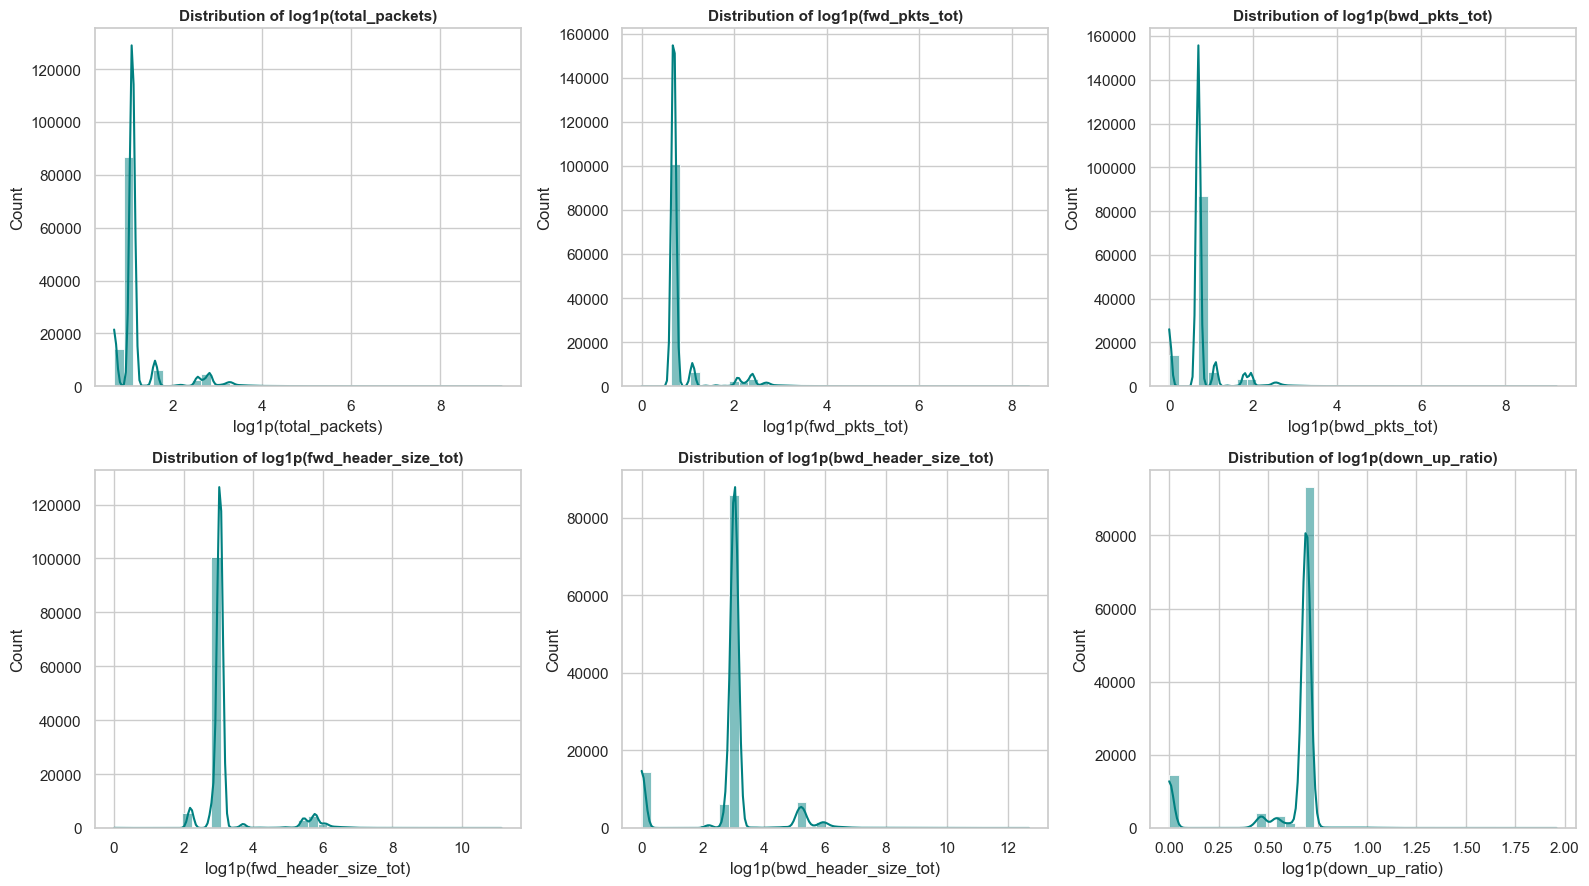

In [11]:
key_features = ['total_packets', 'fwd_pkts_tot', 'bwd_pkts_tot', 
                'fwd_header_size_tot', 'bwd_header_size_tot', 'down_up_ratio']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(key_features):
    log_vals = np.log1p(df_reg[col].clip(lower=0))
    sns.histplot(log_vals, bins=40, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f"Distribution of log1p({col})", fontsize=11, fontweight='bold')
    axes[i].set_xlabel(f"log1p({col})")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()


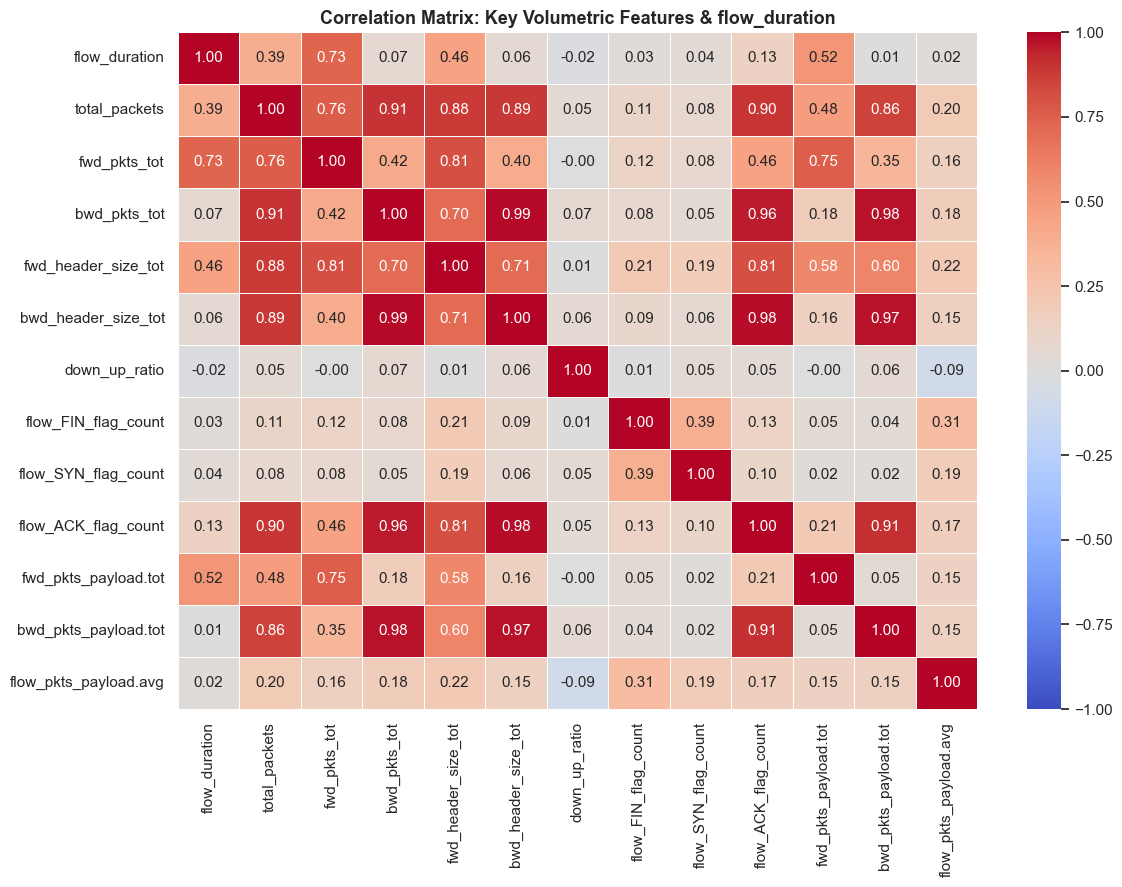

In [12]:
corr_cols = ['flow_duration', 'total_packets', 'fwd_pkts_tot', 'bwd_pkts_tot',
             'fwd_header_size_tot', 'bwd_header_size_tot', 'down_up_ratio',
             'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_ACK_flag_count',
             'fwd_pkts_payload.tot', 'bwd_pkts_payload.tot', 'flow_pkts_payload.avg']

corr_matrix = df_reg[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix: Key Volumetric Features & flow_duration", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observations from Correlation Analysis:**
1. `fwd_pkts_tot` and `fwd_header_size_tot` exhibit near-perfect collinearity ($r = 0.99$), since header bytes naturally scale proportionally with packet counts.
2. The engineered feature `total_packets` correlates strongly with its constituent features ($r = 0.88$ with forward packets, $r = 0.89$ with backward packets).
3. The linear correlations between individual features and raw `flow_duration` are moderate ($r \approx 0.28$ to $0.44$), indicating that the feature-to-target relationship is predominantly non-linear.


## 10. Predictor vs. Target Bivariate Relationships

We plot bivariate relationships between key predictors and `flow_duration` in log-log scale to uncover operational patterns.


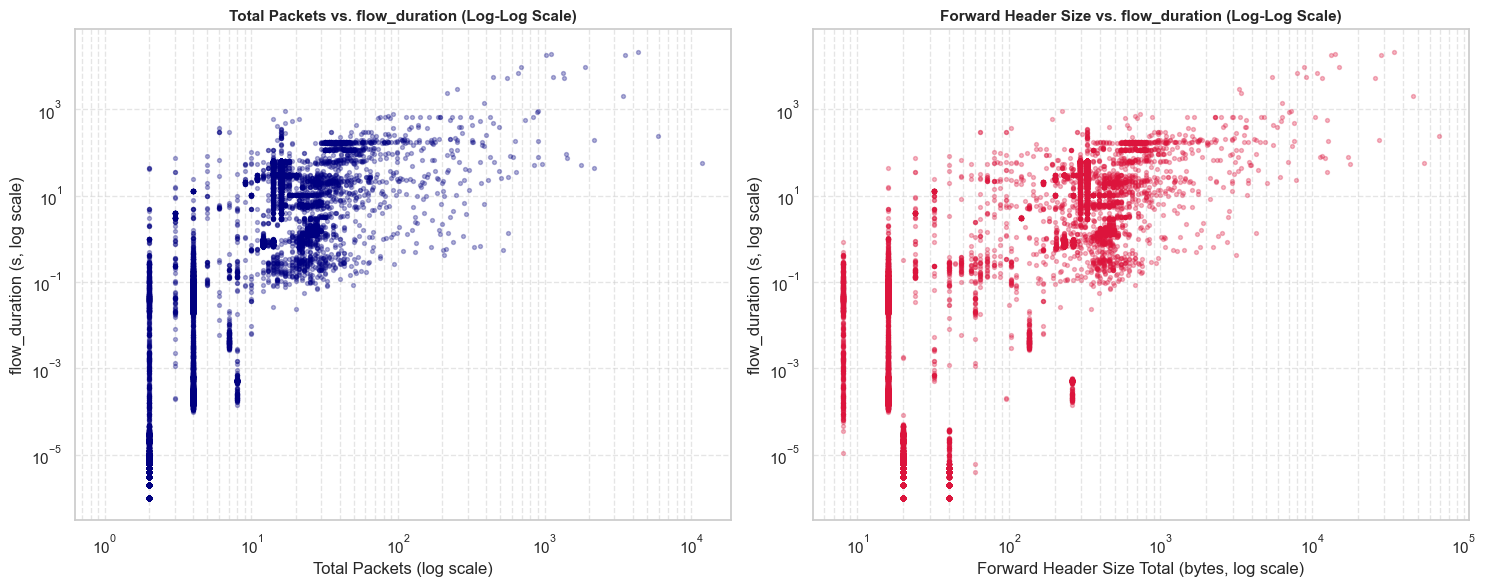

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter 1: total_packets vs flow_duration
axes[0].scatter(df_reg['total_packets'], df_reg[target], alpha=0.3, s=8, color='navy')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Total Packets (log scale)')
axes[0].set_ylabel('flow_duration (s, log scale)')
axes[0].set_title('Total Packets vs. flow_duration (Log-Log Scale)', fontsize=11, fontweight='bold')
axes[0].grid(True, which="both", ls="--", alpha=0.5)

# Scatter 2: fwd_header_size_tot vs flow_duration
axes[1].scatter(df_reg['fwd_header_size_tot'], df_reg[target], alpha=0.3, s=8, color='crimson')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Forward Header Size Total (bytes, log scale)')
axes[1].set_ylabel('flow_duration (s, log scale)')
axes[1].set_title('Forward Header Size vs. flow_duration (Log-Log Scale)', fontsize=11, fontweight='bold')
axes[1].grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()


**Observation on Bivariate Patterns:**
- **Microsecond Regime:** At low packet volumes (1–4 packets), flows bifurcate sharply: many complete in microseconds ($< 10^{-4}$ s), while a subset experiences latency delays ($> 10^1$ s).
- **Monotonic Regime:** Above 100 packets, duration shows a strong monotonic lower bound—transferring large volumes mechanically requires sustained duration.
- This piecewise, threshold-driven relationship highlights why non-linear tree-based models outperform simple linear baselines.


## 11. Deterministic Train/Test Partitioning & Split Storage

### Methodological Architecture: Why Save Split Indices in JSON Instead of Separate CSVs?

In production machine learning pipelines and research benchmarking, storing deterministic **split indices in a structured JSON file** (`regression_split_indices.json`) is vastly superior to exporting separate `X_train.csv` and `X_test.csv` files for four fundamental reasons:

1. **Single Source of Truth & Zero Data Duplication (Storage Efficiency):**
   - The cleaned dataset `RT_IOT2022_cleaned.csv` occupies ~50 MB.
   - Saving separate `X_train.csv`, `X_test.csv`, `y_train.csv`, and `y_test.csv` would duplicate 100% of the dataset, adding 80–100 MB of redundant files to the repository and Git history.
   - In contrast, storing the exact integer row index arrays in a lightweight text file (`regression_split_indices.json`, ~832 KB) guarantees 100% byte-for-byte reproducibility with zero storage bloat.

2. **Strict Prevention of Data Leakage (Isolated Preprocessing):**
   - If preprocessed or scaled data (`X_train_scaled.csv`) were saved directly, subsequent experiments involving different scalers (RobustScaler, MinMaxScaler), encoders, or polynomial features would risk accidentally mixing train and test statistics.
   - Storing pure row indices guarantees that any notebook loads the raw data, partitions strictly on index boundaries, and fits scalers/transformers **exclusively on `X_train`** before transforming `X_test`.

3. **Flexibility for Pipeline Evolution and Experimentation:**
   - As feature engineering evolves (e.g., adding `total_packets` or testing raw vs. `log1p` target scales), saving indices allows all 10 algorithms to evaluate on the exact same sample boundaries without having to regenerate multiple heavy CSV files.

4. **Human-Readable Transparency & Version Control:**
   - Unlike opaque binary serialization formats (`.npz` or `.pkl`), a `.json` file can be opened directly in VS Code, Notepad, or GitHub to inspect metadata, verify row counts, and ensure complete transparency across team members.


Training set: 94,337 samples (80.0%)
Testing set:  23,585 samples (20.0%)
Feature count: 53 features
Split indices saved successfully to 'regression_split_indices.json' (Human-readable JSON)


C:\Users\LAKSHMI NARAYANA\AppData\Local\Temp\ipykernel_29408\878963384.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=split_df, x='Subset', y='Samples', palette=['#1565c0', '#e65100'], ax=ax)


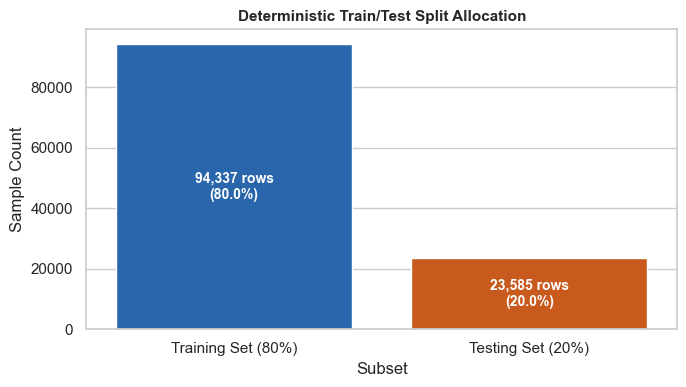

In [14]:
X = df_reg.drop(columns=[target])
y = df_reg[target]

# Deterministic 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

train_indices = X_train.index.to_numpy()
test_indices = X_test.index.to_numpy()

# Format human-readable JSON split structure
split_dict = {
    "metadata": {
        "dataset": "RT_IOT2022_cleaned.csv",
        "description": "Deterministic 80/20 train/test split row indices for RT_IOT2022 regression",
        "random_state": 42,
        "test_size": 0.20,
        "total_samples": len(df_reg),
        "train_samples": len(train_indices),
        "test_samples": len(test_indices)
    },
    "train_indices": train_indices.tolist(),
    "test_indices": test_indices.tolist()
}

split_filename = "regression_split_indices.json"
save_paths = []
if os.path.exists("regression"):
    save_paths.append("regression/" + split_filename)
save_paths.append(split_filename)

json_content = '{\n'
json_content += '  "metadata": ' + json.dumps(split_dict['metadata'], indent=2).replace('\n', '\n  ') + ',\n'
json_content += '  "train_indices": ' + json.dumps(split_dict['train_indices']) + ',\n'
json_content += '  "test_indices": ' + json.dumps(split_dict['test_indices']) + '\n'
json_content += '}\n'

for p in set(save_paths):
    with open(p, 'w', encoding='utf-8') as f:
        f.write(json_content)

print(f"Training set: {X_train.shape[0]:,} samples ({len(X_train)/len(df_reg)*100:.1f}%)")
print(f"Testing set:  {X_test.shape[0]:,} samples ({len(X_test)/len(df_reg)*100:.1f}%)")
print(f"Feature count: {X_train.shape[1]} features")
print(f"Split indices saved successfully to '{split_filename}' (Human-readable JSON)")

# Visualize Train/Test Allocation
fig, ax = plt.subplots(figsize=(7, 4))
split_df = pd.DataFrame({
    'Subset': ['Training Set (80%)', 'Testing Set (20%)'],
    'Samples': [len(X_train), len(X_test)]
})
sns.barplot(data=split_df, x='Subset', y='Samples', palette=['#1565c0', '#e65100'], ax=ax)
ax.set_title("Deterministic Train/Test Split Allocation", fontsize=11, fontweight='bold')
ax.set_ylabel("Sample Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,} rows\n({p.get_height()/len(df_reg)*100:.1f}%)", 
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()


## 12. Leakage-Free Preprocessing Pipeline Architecture

Different regression families impose distinct requirements:
- **Linear, Regularized, SVR, and Distance-Based (KNN) Models:** Require one-hot encoding for categorical variables (`proto`, `service`) and z-score standard scaling (`StandardScaler`) for numerical predictors.
- **Tree-Based Ensembles (Decision Trees, Random Forest, Gradient Boosting):** Invariant to monotonic scaling; require one-hot encoding of categoricals with numerical features passed through unchanged.

We construct production `ColumnTransformer` pipelines, ensuring that transformers are fitted exclusively on `X_train`.


In [15]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"Numerical features ({len(num_cols)}): {len(num_cols)} features")

# Pipeline 1: Scaled Preprocessor (Linear, Ridge, Lasso, ElasticNet, SVR, KNN)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

# Pipeline 2: Unscaled Preprocessor (Tree Ensembles)
preprocessor_trees = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

# Fit on training data only to verify pipeline integrity
preprocessor_scaled.fit(X_train)
preprocessor_trees.fit(X_train)

transformed_scaled_shape = preprocessor_scaled.transform(X_train.iloc[:5]).shape
print(f"Transformed feature count after one-hot encoding: {transformed_scaled_shape[1]}")


Categorical features (2): ['proto', 'service']
Numerical features (51): 51 features


Transformed feature count after one-hot encoding: 64


## 13. Preprocessing Verification Summary and Integrity Checks

We run final automated assertions to confirm complete pipeline correctness.


In [16]:
print("=== REGRESSION PREPROCESSING VERIFICATION SUMMARY ===")
print(f"1. Raw Dataset Shape:             {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
print(f"2. Cleaned Dataset Shape:         {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"3. Excluded Leakage Columns:      {len(drop_cols)}")
print(f"4. Final Regression Predictors:   {X_train.shape[1]}")
print(f"5. Engineered Features:          1 ('total_packets')")
print(f"6. Training Rows:                {X_train.shape[0]:,} (80.0%)")
print(f"7. Testing Rows:                 {X_test.shape[0]:,} (20.0%)")
print(f"8. Target Absent from Features:  {target not in X_train.columns}")
print(f"9. Missing Values in Train/Test: {X_train.isnull().sum().sum()} / {X_test.isnull().sum().sum()}")
print(f"10. Split Disjointness Check:    {len(set(train_indices).intersection(set(test_indices)))} overlapping rows")
print(f"11. Indices Persisted:           '{split_filename}' (JSON format)")
print("\nAll data cleaning, feature engineering, and preprocessing checks PASSED successfully.")


=== REGRESSION PREPROCESSING VERIFICATION SUMMARY ===
1. Raw Dataset Shape:             123,117 rows, 85 columns
2. Cleaned Dataset Shape:         117,922 rows, 83 columns
3. Excluded Leakage Columns:      30
4. Final Regression Predictors:   53
5. Engineered Features:          1 ('total_packets')
6. Training Rows:                94,337 (80.0%)
7. Testing Rows:                 23,585 (20.0%)
8. Target Absent from Features:  True
9. Missing Values in Train/Test: 0 / 0
10. Split Disjointness Check:    0 overlapping rows
11. Indices Persisted:           'regression_split_indices.json' (JSON format)

All data cleaning, feature engineering, and preprocessing checks PASSED successfully.
